<a href="https://colab.research.google.com/github/ODZ-UJF-AV-CR/SPACEDOS-ISS-RadLab/blob/main/SPACEDOS_ISS_2020_flux.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPACEDOS02

In [4]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta, timezone
from IPython.display import Image as ImageDisp
from pandas import DataFrame
import string
import os
import glob
import matplotlib.pyplot as plt
import matplotlib
import gdown
%matplotlib inline


# SPACEDOS ISS 2020-2021

Launch Soyuz MS-17: 14 October 2020, 05:45:04
- Launch site: Baikonur
- Launch pad: Site 31
- Altitude: 420 km
- Inclination: 51,6°

### Docking ISS: 14 October 2020, 08:48:47 UTC
### Undocking ISS: 17 April 2021, 01:34 UTC
Landing Soyuz MS-17: 17 April 2021, 04:55 UTC
- Landing site: Kazakh Steppe

_Note: Gaps in measurement after measurement number 678000_

## Orbit

In [5]:
# Copy orbital data from ISS-coords-SPACEDOS-2020.tsv to temporary file
file_id = "1I-Pot6Nzn2XG22y4vRXj2TN343FdlIiW" # 2020
gdown.download(f"https://drive.google.com/uc?id={file_id}", "orbit.csv", quiet=True)

'orbit.csv'

In [6]:
# Read temporary file
cols = ['UTC', 'B', 'L']
orbit = pd.read_csv("orbit.csv", sep='\t', header=0, usecols=cols)

orbit.reset_index(drop=True, inplace=True)
orbit["UTC"] = pd.to_datetime(orbit["UTC"], unit="s", utc=True)

orbit.head()

,UTC,B,L
0,2020-10-14 05:45:04+00:00,43328.0,1.78487
1,2020-10-14 05:45:05+00:00,43346.9,1.78661
2,2020-10-14 05:45:06+00:00,43365.8,1.78835
3,2020-10-14 05:45:07+00:00,43384.7,1.79008
4,2020-10-14 05:45:08+00:00,43403.5,1.79182


## Flux

In [7]:
# Copy data from 2020_flux.csv to temporary file
file_id = "1-tb8oBoYU48y3F6xlWEaA8Rj3tgIuuHW"
gdown.download(f"https://drive.google.com/uc?id={file_id}", "data.csv", quiet=True)

'data.csv'

In [8]:
# Read temporary file
rc = pd.read_csv("data.csv", sep=',', header=0, comment='*')#,engine='python' )

rc.reset_index(drop=True, inplace=True)
rc.head()

,measurement,time,flux,original_time
0,0,7509128.0,1.0,7509128.0
1,1,7509139.0,1.0,7509139.0
2,2,7509149.0,0.0,7509149.0
3,3,7509160.0,1.0,7509160.0
4,4,7509170.0,1.0,7509170.0


In [9]:
rc['time'] = pd.to_numeric(rc['time'], errors='coerce')

# launch time
ref_seconds = 7_587_246.0
ref_abs = pd.Timestamp('2020-10-14 05:45:04', tz='UTC')

t0 = ref_abs - pd.to_timedelta(ref_seconds, unit='s')

# add absolute time
rc['abs_time'] = t0 + pd.to_timedelta(rc['time'], unit='s')

Text(0, 0.5, 'Hits per 10 s')

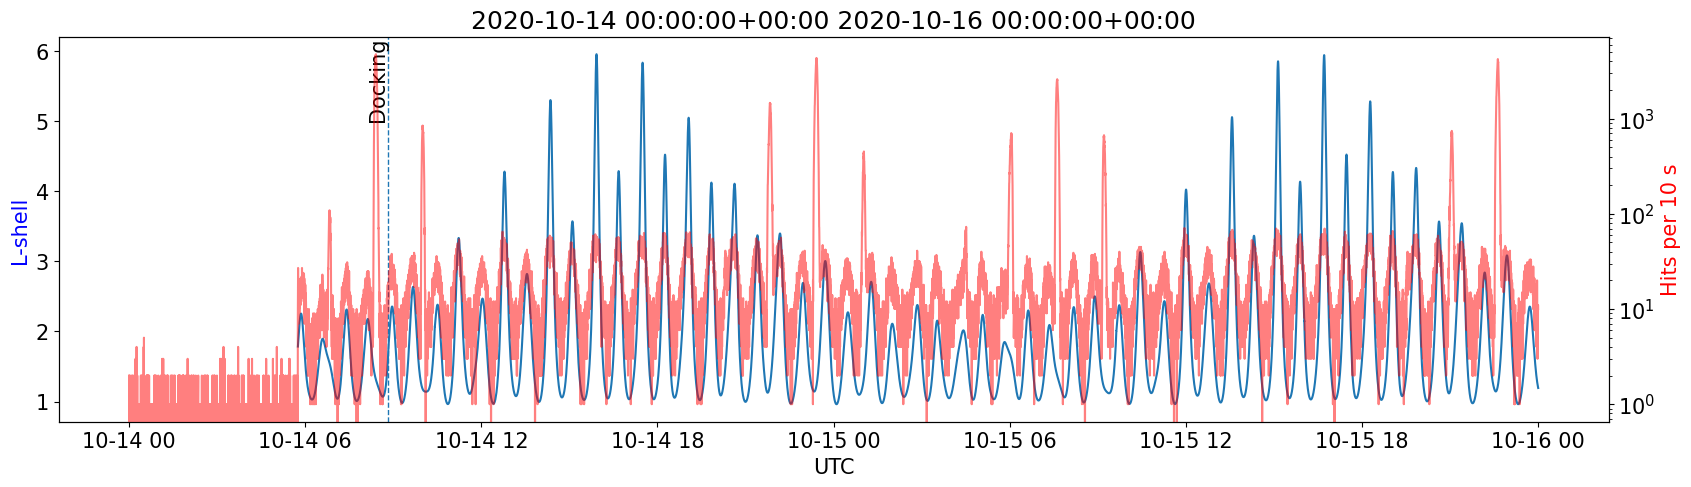

In [10]:
# --- zoom window ---
tmin = pd.Timestamp("2020-10-14 00:00:00", tz="UTC")
tmax = pd.Timestamp("2020-10-16 00:00:00", tz="UTC")
zoom = orbit.loc[orbit["UTC"] < tmax].loc[orbit["UTC"] > tmin]

# --- Docking time ---
mark_t = pd.Timestamp("2020-10-14 08:48:47", tz="UTC")

plt.figure(figsize=(20,5))
matplotlib.rcParams.update({'font.size': 15})

ax1 = plt.gca()
ax1.plot(zoom["UTC"], zoom["L"], label="L")
ax1.set_xlabel("UTC")
ax1.set_ylabel("L-shell", color='blue')

# Docking mark
ax1.axvline(mark_t, linestyle="--", linewidth=1)
ax1.text(mark_t, ax1.get_ylim()[1], "Docking",
         rotation=90, va="top", ha="right")
ax1.set_title(str(tmin)+" "+str(tmax))

ax2 = ax1.twinx()

ax2.set_yscale('log')
#ax2.set_ylim(1,500)

zoom_data = rc.loc[rc["abs_time"] < tmax].loc[rc["abs_time"] > tmin]
ax2.plot(zoom_data["abs_time"], zoom_data["flux"], label="Flux", color='red', alpha=0.5)
ax2.set_ylabel("Hits per 10 s", color='red')




Text(0, 0.5, 'Hits per 10 s')

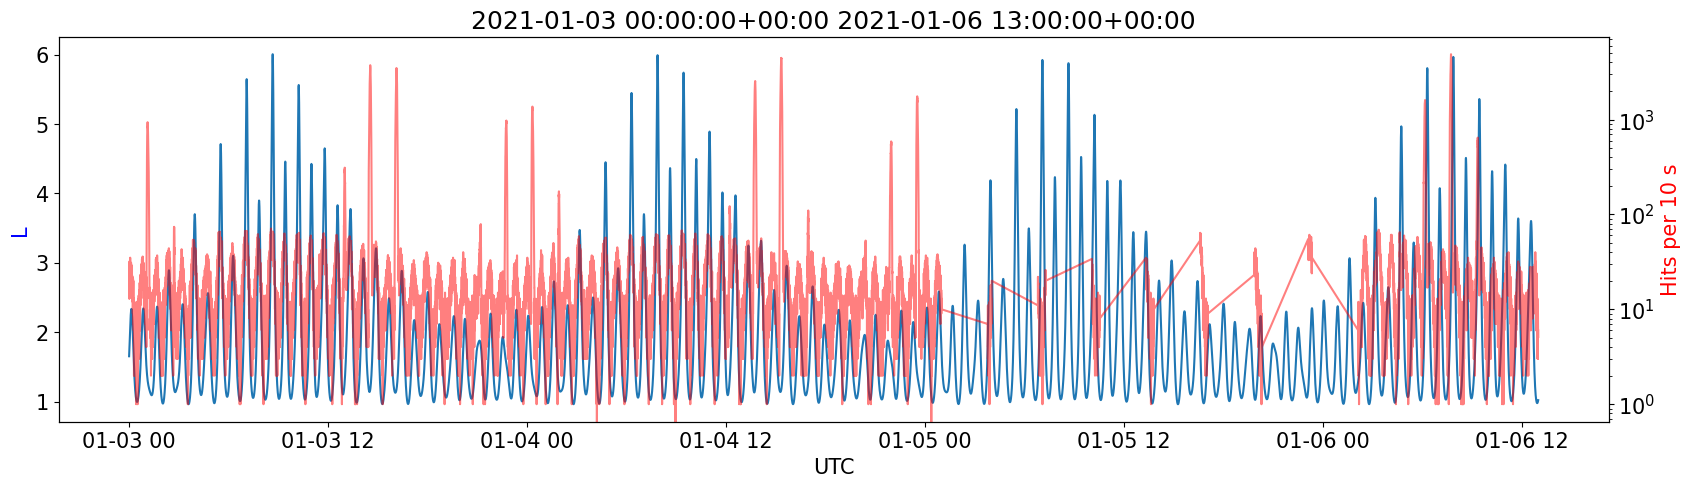

In [11]:
# --- zoom window ---
tmax = pd.Timestamp("2021-01-06 13:00:00", tz="UTC") # the first power interruption
tmin = pd.Timestamp("2021-01-03 00:00:00", tz="UTC")
zoom = orbit.loc[orbit["UTC"] < tmax].loc[orbit["UTC"] > tmin]

plt.figure(figsize=(20,5))
matplotlib.rcParams.update({'font.size': 15})

ax1 = plt.gca()
ax1.plot(zoom["UTC"], zoom["L"], label="L")
ax1.set_xlabel("UTC")
ax1.set_ylabel("L", color='blue')
ax1.set_title(str(tmin)+" "+str(tmax))

ax2 = ax1.twinx()

ax2.set_yscale('log')
#ax2.set_ylim(1,500)

zoom_data = rc.loc[rc["abs_time"] < tmax].loc[rc["abs_time"] > tmin]
ax2.plot(zoom_data["abs_time"], zoom_data["flux"], label="Flux", color='red', alpha=0.5)
ax2.set_ylabel("Hits per 10 s", color='red')


